# RankNet on MSLR
### Learning to Rank — Pairwise Neural Approach
---
**Dataset**: MSLR 10K  
**Model**: ScoringMLP (MLP) trained with RankNet pairwise BCE  
**Loss**: RankNet BCE  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **RankNet**, a foundational pairwise Learning-to-Rank algorithm.
The network intially predict relevance scores for each document. Then, Calculates the loss based on the score difference for every pair of documents.
**pairwise Binary Cross-Entropy loss** that directly optimises the relative ordering of documents.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | Pairwise loss intuition (RankNet BCE) |
| 5    | Training and testing the Baseline model |
| 6    | Training and testing the Regularized model |
| 7    | Multiseed Evaluation for both models |
| 8    | 5-Fold Evaluation (Standard LETOR Folds) |
| 9    | Ablation study across 4 architectures |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Pairwise Approaches", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

- Downloading dataset from drive

In [2]:
import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=6075be1f-5993-4bde-b01e-303f32f289cd
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [00:27<00:00, 51.8MB/s]


'mslr.zip'

- Extracting the zip file

In [3]:
# ── Extract MQ2008 dataset ────────────────────────────────────────────────────
import zipfile, os

ZIP_PATH  = "/content/mslr.zip"
DATA_PATH = "/content/MSLR"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Imports & Configuration

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data_mslr     import load_fold
from ltr.models   import ScoringMLP
from ltr.train    import train, train_multiseed, set_seed
from ltr.metrics  import mean_ndcg, per_query_ndcg, paired_significance
from ltr.evaluate import cross_fold_eval

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
PyTorch : 2.11.0+cu128


## Step 3 · Data Loading

In [ ]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print(f"Batch: {len(sample_qids)} queries")
print(f"Query 0 features shape: {sample_feats[0].shape}")
print(f"Query 0 labels        : {sample_labels[0].tolist()}")


  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
Batch: 4 queries
Query 0 features shape: torch.Size([168, 111])
Query 0 labels        : [1.0, 1.0, 3.0, 2.0, 2.0, 3.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.0, 2.0, 0.0, 1.0, 2.0, 2.0, 1.0, 1.0, 2.0, 2.0, 2.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 2.0, 3.0, 2.0, 0.0, 2.0, 2.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 4.0, 1.0, 2.0, 2.0, 2.0, 2.0, 0.0, 1.0, 0.0, 1.0, 2.0, 0.0, 2.0, 0.0, 2.0, 2.0, 2.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 4.0, 0.0, 1.0, 2.0, 0.0, 2.0, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 1.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 2.0, 4.0, 0.0, 2.0, 2.0, 0.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 2.0, 2.0, 1.0, 2.0, 1.0, 0.0, 2.0, 2.0, 1.0, 0.0, 0.0, 1.0, 0.0, 2.0, 1.0, 0.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, 0.0, 2.0, 0.0, 2.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.

## Step 4 · The Pairwise Loss (RankNet BCE)

To calculate the probability that document $i$ is better than document $j$, we pass
their score difference through a sigmoid function:

$$P_{ij} = \sigma(s_i - s_j)$$

The loss is then the negative log of that probability:

$$L = -\log \sigma(s_i - s_j)$$

This is equivalent to `binary_cross_entropy_with_logits(s_i - s_j, target=1)` for all
valid pairs where `label_i > label_j`.


## Step 5 · Training (Single Fold, Baseline Run)

Early stopping is based on **validation NDCG@10**.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(train_losses, val_ndcgs, title="Training Curves"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # 1. Find the best epoch (add 1 because epochs start at 1 in our plot)
    best_epoch = np.argmax(val_ndcgs) + 1
    best_val = val_ndcgs[best_epoch - 1]

    # 2. Draw the vertical dotted line for the best epoch
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.8,
                label=f'Best Epoch ({best_epoch})')

    # Plot Train Loss (Left Y-Axis)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Train Loss', color='tab:red')
    ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='tab:red', marker='o')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Plot Val NDCG (Right Y-Axis)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation NDCG@10', color='tab:blue')
    ax2.plot(range(1, len(val_ndcgs) + 1), val_ndcgs, label='Val NDCG@10', color='tab:blue', marker='s')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # Add legends for both axes combined
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    fig.suptitle(title)
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0).to(DEVICE)

best_model, last_model, train_loss_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="ranknet",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Train Loss: 0.5992 | Val NDCG@10: 0.4041  ← best
Epoch 02/50 | Train Loss: 0.5909 | Val NDCG@10: 0.4172  ← best
Epoch 03/50 | Train Loss: 0.5874 | Val NDCG@10: 0.4109
Epoch 04/50 | Train Loss: 0.5848 | Val NDCG@10: 0.4182  ← best
Epoch 05/50 | Train Loss: 0.5832 | Val NDCG@10: 0.4263  ← best
Epoch 06/50 | Train Loss: 0.5815 | Val NDCG@10: 0.4269  ← best
Epoch 07/50 | Train Loss: 0.5801 | Val NDCG@10: 0.4257
Epoch 08/50 | Train Loss: 0.5791 | Val NDCG@10: 0.4221
Epoch 09/50 | Train Loss: 0.5780 | Val NDCG@10: 0.4311  ← best
Epoch 10/50 | Train Loss: 0.5768 | Val NDCG@10: 0.4286
Epoch 11/50 | Train Loss: 0.5755 | Val NDCG@10: 0.4276
Epoch 12/50 | Train Loss: 0.5743 | Val NDCG@10: 0.4340  ← best
Epoch 13/50 | Train Loss: 0.5727 | Val NDCG@10: 0.4289
Epoch 14/50 | Train Loss: 0.5718 | Val NDCG@10: 0.4303
Epoch 15/50 | Train Loss: 0.5714 | Val NDCG@10: 0.4267
Epoch 16/50 | Train Loss: 0.5704 | Val NDCG@10: 0.4334
Epoch 17/50 | Train Loss: 0.5689 | Val NDCG@10: 0.4316
Epoch 18/

## Training Curve

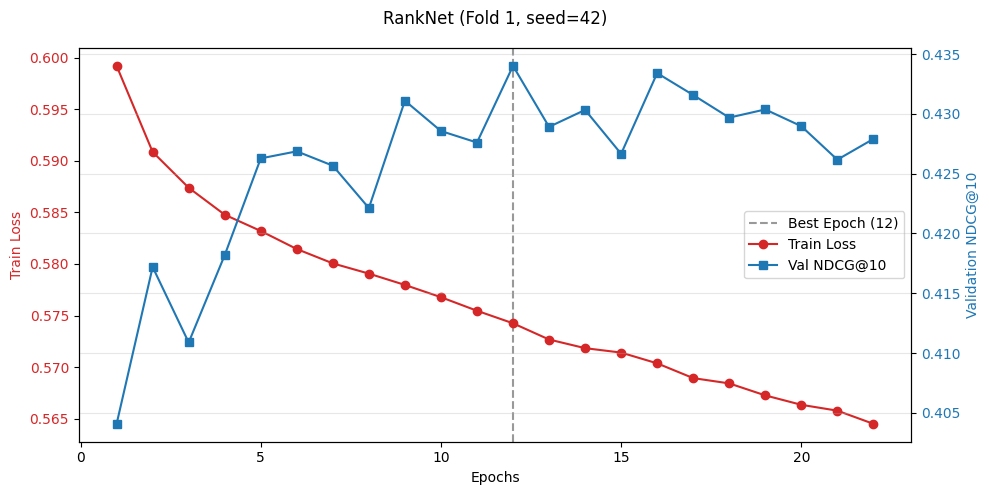

In [ ]:
plot_training_curves(train_loss_history,val_ndcg_history, "RankNet (Fold 1, seed=42)")


## Key Takeaways:

- Training loss is continuously decresing while validation NDCG@10 stopped increasing from **epoch 12**. This is a case of the model overfitting over the training data.

## Next Steps:

I will use Dropout Regularisation and see if the model generalizes over the data.

## Testing (single fold, single seed, baseline model)

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3926
  NDCG@3  : 0.3879
  NDCG@5  : 0.3975
  NDCG@10 : 0.4186


### Expected Outcomes:
- The regularized model should give higher score over the test data.

## Step 6: Training(single fold, single seed, Regularization(dropout=0.2))

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2).to(DEVICE)

best_model_reg, last_model_reg, train_loss_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="ranknet",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Train Loss: 0.6046 | Val NDCG@10: 0.4037  ← best
Epoch 02/50 | Train Loss: 0.5975 | Val NDCG@10: 0.4142  ← best
Epoch 03/50 | Train Loss: 0.5945 | Val NDCG@10: 0.4082
Epoch 04/50 | Train Loss: 0.5928 | Val NDCG@10: 0.4154  ← best
Epoch 05/50 | Train Loss: 0.5916 | Val NDCG@10: 0.4192  ← best
Epoch 06/50 | Train Loss: 0.5902 | Val NDCG@10: 0.4169
Epoch 07/50 | Train Loss: 0.5896 | Val NDCG@10: 0.4190
Epoch 08/50 | Train Loss: 0.5881 | Val NDCG@10: 0.4209  ← best
Epoch 09/50 | Train Loss: 0.5875 | Val NDCG@10: 0.4220  ← best
Epoch 10/50 | Train Loss: 0.5868 | Val NDCG@10: 0.4230  ← best
Epoch 11/50 | Train Loss: 0.5859 | Val NDCG@10: 0.4263  ← best
Epoch 12/50 | Train Loss: 0.5847 | Val NDCG@10: 0.4267  ← best
Epoch 13/50 | Train Loss: 0.5846 | Val NDCG@10: 0.4233
Epoch 14/50 | Train Loss: 0.5838 | Val NDCG@10: 0.4265
Epoch 15/50 | Train Loss: 0.5838 | Val NDCG@10: 0.4216
Epoch 16/50 | Train Loss: 0.5827 | Val NDCG@10: 0.4274  ← best
Epoch 17/50 | Train Loss: 0.5821 | Val N

## Training Curve

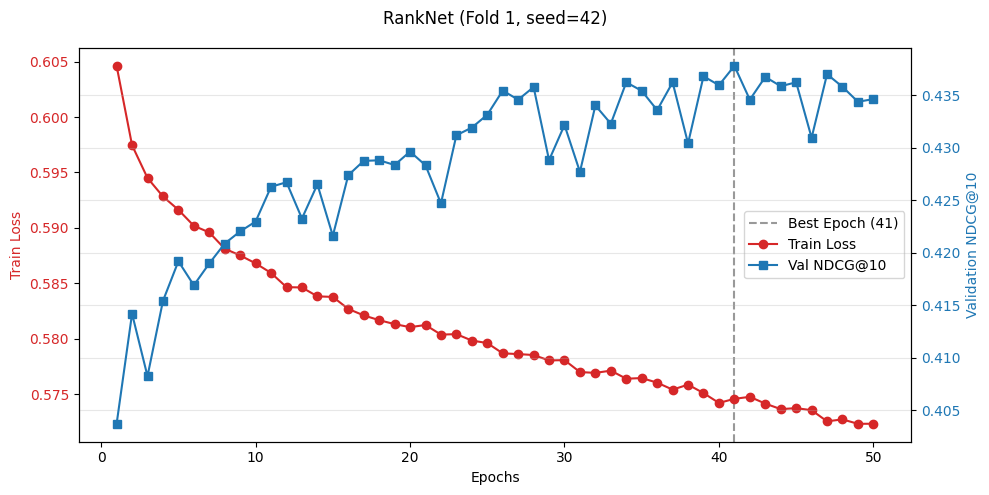

In [ ]:
plot_training_curves(train_loss_history,val_ndcg_history, "RankNet (Fold 1, seed=42)")

## Key Takeaways:

- The best validation scores in both cases are **0.4340** and **0.4378**(Regularization). But the difference is a bit low.
- Regulization is very helpful because the validation score keeps on increasing until the training loss flattens.

## Next Steps:

- Since the last 9 epochs didn't gave the best validation score. I will not do further training.
- Evaluate the base model and regularised model with test data.

## Expected Outcomes:

- The regularized model should give better Results than baseline model.

## Testing

In [ ]:
test_ndcg = mean_ndcg(trained_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.3859
  NDCG@3  : 0.3902
  NDCG@5  : 0.3962
  NDCG@10 : 0.4199


## Results:

| Metric | Baseline | Regularized(0.2) |   
| ------ | -------- | ---------------- |
| NDCG@1 | 0.3926 | 0.386 |   
| NDCG@3 | 0.3879 | 0.390 |   
| NDCG@5 | 0.3975 | 0.396 |   
| NDCG@10 | 0.4186 | 0.420 |  

## Key Takeaways:

- There is a good difference between the best validation score. But in the test results baseline and Regularized are competing at different K.
- Baseline(1,5) and regularized(3,10)
- It's not underfitting because the training loss is smoothly decreasing until the end.
- Val and test data have 2000 queries each and over 100docs/query. So, There will be less noise.
- It solves overfitting but i couldn't understand why the result is same as baseline.

## Next Steps:

- I will run the models over 3 seeds and see if they are the same in all cases.

## Step 7: Training and Testing both models with 3 different seeds

### Baseline Model

In [ ]:
ranknet_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0),
    mode="ranknet",
    base_path=DATA_PATH,
    folds=[1],
    data_loader_fn=load_fold,
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.3853 ± 0.0080
  NDCG@3  : 0.3875 ± 0.0021
  NDCG@5  : 0.3968 ± 0.0013
  NDCG@10 : 0.4192 ± 0.0006

═══════════════════════════════════════════════════════
  OVERALL RESULTS (RANKNET)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3853 ± 0.0080
  NDCG@3  : 0.3875 ± 0.0021
  NDCG@5  : 0.3968 ± 0.0013
  NDCG@10 : 0.4192 ± 0.0006
═══════════════════════════════════════════════════════



### Regularised Model

In [ ]:
ranknet_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2),
    mode="ranknet",
    base_path=DATA_PATH,
    folds=[1],
    data_loader_fn=load_fold,
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.3959 ± 0.0077
  NDCG@3  : 0.3945 ± 0.0031
  NDCG@5  : 0.4013 ± 0.0039
  NDCG@10 : 0.4231 ± 0.0025

═══════════════════════════════════════════════════════
  OVERALL RESULTS (RANKNET)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3959 ± 0.0077
  NDCG@3  : 0.3945 ± 0.0031
  NDCG@5  : 0.4013 ± 0.0039
  NDCG@10 : 0.4231 ± 0.0025
═══════════════════════════════════════════════════════



## Results:

| Metric | Baseline | Regularized(0.2) |   
| ------ | -------- | ---------------- |
| NDCG@1 | 0.385 ± 0.008 | 0.396 ± 0.008|   
| NDCG@3 | 0.388 ± 0.002 | 0.395 ± 0.003 |   
| NDCG@5 | 0.397 ± 0.001 | 0.401 ± 0.004 |   
| NDCG@10 | 0.419 ± 0.001 | 0.423 ± 0.003 |

## Key Takeaways:
- So, The Regularization helped the model and we got better results than the baseline model.
- The variance is very low. Therefore, we can get the similar result most of the time.

**Why did it fail earlier?**: The Random seed affected the training and gave us the worst possible sequence of networks.

## Next Step:

- Perform a 5-fold cross validation and check if the Data split is good enough.

## Step 8 · 5-Fold Evaluation (Standard MSLR Folds)

We are using the exact 5 test splits provided by the dataset authors, rather than
shuffling and making our own cross-validation splits. This makes sure our results
can be fairly compared to published papers.


In [5]:
def print_results_table(results, title, k_list=(1, 3, 5, 10)):
    """Pretty-print a cross_fold_eval or train_multiseed results dict."""
    summary = results.get("overall", results.get("summary", {}))
    print(f"\n{'═'*45}")
    print(f"  {title}")
    print(f"{'═'*45}")
    print(f"{'Metric':<10}  {'Mean':>8}  {'Std':>8}")
    print(f"{'─'*45}")
    for k in k_list:
        if k in summary:
            m, s = summary[k]["mean"], summary[k]["std"]
            print(f"NDCG@{k:<5}  {m:>8.4f}  {s:>8.4f}")
    print(f"{'═'*45}")


In [6]:
ranknet_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2),
    mode="ranknet",
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    data_loader_fn=load_fold,
    seeds=[42],
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)

print_results_table(ranknet_results, "RANKNET — 5-Fold Results")



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.3859 ± 0.0000
  NDCG@3  : 0.3902 ± 0.0000
  NDCG@5  : 0.3962 ± 0.0000
  NDCG@10 : 0.4199 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════
  [Fold 2] Loading train split and computing normalization stats...


  [Fold 2] Loading val split (using train stats)...


...

  [Fold 4] Loading test split (using train stats)...


  Fold 4: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.3935 ± 0.0000
  NDCG@3  : 0.4006 ± 0.0000
  NDCG@5  : 0.4097 ± 0.0000
  NDCG@10 : 0.4321 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════
  [Fold 5] Loading train split and computing normalization stats...


  [Fold 5] Loading val split (using train stats)...


  [Fold 5] Loading test split (using train stats)...


  Fold 5: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4042 ± 0.0000
  NDCG@3  : 0.4053 ± 0.0000
  NDCG@5  : 0.4141 ± 0.0000
  NDCG@10 : 0.4372 ± 0.0000

═══════════════════════════════════════════════════════
  OVERALL RESULTS (RANKNET)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.3952 ± 0.0061
  NDCG@3  : 0.3965 ± 0.0063
  NDCG@5  : 0.4041 ± 0.0069
  NDCG@10 : 0.4273 ± 0.0064
═══════════════════════════════════════════════════════


═════════════════════════════════════════════
  RANKNET — 5-Fold Results
═════════════════════════════════════════════
Metric          Mean       Std
─────────────────────────────────────────────
NDCG@1        0.3952    0.0061
NDCG@3        0.3965    0.0063
NDCG@5        0.4041    0.0069
NDCG@10       0.4273    0.0064
═════════════════════════════════════════════


## Key Takeaways:

- The variance across different folds is low. The model's performance is stable.

## Next Steps:
- Perform an ablation study to see how the results vary with depth.

## Save Results

In [7]:
import json

os.makedirs("/content/ltr_results", exist_ok=True)

def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

with open("/content/ltr_results/ranknet_results_mslr.json", "w") as f:
    json.dump(to_serialisable(ranknet_results), f, indent=2)

print("Results saved to /content/ltr_results/ranknet_results_mslr.json")


Results saved to /content/ltr_results/ranknet_results_mslr.json


## Step 9 · Ablation Study — Architecture Comparison

We lock the data to **Fold 1** and swap out the underlying network architecture,
keeping everything else identical. This isolates the impact of depth and
dropout regularization on NDCG@10.

| Config | Hidden dims | Dropout |
|---|---|---|
| Linear | `[]` | 0.0 |
| Shallow | `[64, 32]` | 0.0 |
| Deep | `[128, 64, 32]` | 0.2 |


In [8]:
# ── Lock data to Fold 1 ───────────────────────────────────────────────────────
train_loader_f1, val_loader_f1, test_loader_f1 = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

# ── Ablation configurations ───────────────────────────────────────────────────
ablation_configs = {
    "Linear":      {"hidden_dims": [],              "dropout": 0.0},
    "Shallow": {"hidden_dims": [64, 32],         "dropout": 0.0},
    "Deep":        {"hidden_dims": [128, 64, 32],"dropout": 0.2},
}

ablation_results = {}

for arch_name, cfg in ablation_configs.items():
    print(f"\nTraining {arch_name} ...")
    result = train_multiseed(
        model_fn=lambda h=cfg["hidden_dims"], d=cfg["dropout"]: ScoringMLP(111, h, d),
        train_loader=train_loader_f1,
        val_loader=val_loader_f1,
        test_loader=test_loader_f1,
        mode="ranknet",
        seeds=[42],
        k_list=K_LIST,
        device=DEVICE,
        epochs=50,
        patience=10,
        verbose=False,
    )
    ablation_results[arch_name] = result["summary"]
    ndcg10 = result["summary"][10]
    print(f"  NDCG@10: {ndcg10['mean']:.4f} ± {ndcg10['std']:.4f}")


  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))

Training Linear ...
  NDCG@10: 0.3701 ± 0.0000

Training Shallow ...
  NDCG@10: 0.4219 ± 0.0000

Training Deep ...
  NDCG@10: 0.4217 ± 0.0000


In [14]:
# ── Ablation results table ────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  ABLATION STUDY — NDCG@10 (Fold 1,single seed)")
print(f"{'═'*65}")
print(f"{'Architecture':<15}  {'NDCG@1':>5}  {'NDCG@3':>5}  {'NDCG@5':>5}  {'NDCG@10':>5}")
print(f"{'─'*65}")
for arch_name, summary in ablation_results.items():
    row = "  ".join(
        f"{summary[k]['mean']:>6.4f}" for k in [1, 3, 5, 10]
    )
    print(f"{arch_name:<15}  {row}")
print(f"{'═'*65}")



═════════════════════════════════════════════════════════════════
  ABLATION STUDY — NDCG@10 (Fold 1,single seed)
═════════════════════════════════════════════════════════════════
Architecture     NDCG@1  NDCG@3  NDCG@5  NDCG@10
─────────────────────────────────────────────────────────────────
Linear           0.3123  0.3283  0.3425  0.3701
Shallow          0.3909  0.3904  0.3980  0.4219
Deep             0.3923  0.3876  0.3974  0.4217
═════════════════════════════════════════════════════════════════


**Baseline**   
NDCG@1       - 0.3952  
NDCG@3       - 0.3965  
NDCG@5       - 0.4041  
NDCG@10- 0.4273  

## Key Takeaways:

- Increasing or Decreasing the depth of the neural network reduces the performance with a reasonable difference.
- Linear(Logistic Regression) performed the worst among them with major difference in NDCG score proving that ranking pattern is not linear.

## Conclusion

- RankNet directly optimises the relative ordering of document pairs, which aligns
more closely with the NDCG metric.
- A simple linear model cannot capture underlying pattern of ranking in MSLR 10K dataset.
- Regularization helps here.